
# CESM2-LE TREFHT Analysis: First 10 Ensemble Members + NASA GISS Overlay

This notebook:

- reads **CESM2-LE TREFHT** for the **first 10 ensemble members**
- reads **all historical + SSP370 chunk files**
- computes **1951–1980 monthly climatology**
- uses the **ensemble-mean climatology** as the reference
- computes **anomalies for each member**
- makes:
  - **ensemble-mean spatial anomaly maps**
  - **global weighted annual mean time series** for all 10 members
  - **SEUS weighted annual mean time series** for all 10 members
- overlays **NASA GISS observations** on the global plot


## 1. Import packages

In [5]:

import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 11



## 2. User settings

Update `GISS_PATH` if your NASA GISS file is stored in a different directory.


In [6]:

TREFHT_DIR = "/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1/TREFHT"
GISS_PATH = "/glade/work/kumar34/GSEI2070_DAT/gistemp1200_GHCNv4_ERSSTv5.nc"

OUTDIR = "./figures_cesm2le"
os.makedirs(OUTDIR, exist_ok=True)

MEMBERS = [
    "LE2-1001.001",
    "LE2-1021.002",
    "LE2-1041.003",
    "LE2-1061.004",
    "LE2-1081.005",
    "LE2-1101.006",
    "LE2-1121.007",
    "LE2-1141.008",
    "LE2-1161.009",
    "LE2-1181.010",
]

CLIMO_START = "1951-01-01"
CLIMO_END   = "1980-12-31"

MAP1_START, MAP1_END = "1981-01-01", "2010-12-31"
MAP2_START, MAP2_END = "2071-01-01", "2100-12-31"

SEUS_LAT_MIN = 25
SEUS_LAT_MAX = 37
SEUS_LON_MIN = 265
SEUS_LON_MAX = 285


## 3. Helper functions

In [7]:

def open_member_dataset(member, variable="TREFHT"):
    hist_files = sorted(glob.glob(os.path.join(
        TREFHT_DIR,
        f"b.e21.BHISTcmip6.f09_g17.{member}.cam.h0.{variable}.*.nc"
    )))
    ssp_files = sorted(glob.glob(os.path.join(
        TREFHT_DIR,
        f"b.e21.BSSP370cmip6.f09_g17.{member}.cam.h0.{variable}.*.nc"
    )))

    files = hist_files + ssp_files

    if len(files) == 0:
        raise FileNotFoundError(f"No files found for member {member}")

    print(f"\nProcessing {member}")
    print(f"  nfiles = {len(files)}")
    print(f"  first  = {os.path.basename(files[0])}")
    print(f"  last   = {os.path.basename(files[-1])}")

    ds = xr.open_mfdataset(
        files,
        combine="nested",
        concat_dim="time",
        engine="netcdf4",
        parallel=False,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    ds = ds.expand_dims({"ensemble": [member]})
    return ds


def annual_mean(da):
    return da.groupby("time.year").mean("time")


def global_weighted_mean_latlon(da):
    weights = xr.DataArray(
        np.cos(np.deg2rad(da["lat"])),
        coords={"lat": da["lat"]},
        dims=["lat"],
    )
    return da.weighted(weights).mean(dim=["lat", "lon"])


def subset_seus(da):
    return da.sel(
        lat=slice(SEUS_LAT_MIN, SEUS_LAT_MAX),
        lon=slice(SEUS_LON_MIN, SEUS_LON_MAX)
    )


def plot_map(da, title, outfile=None, vmin=-4, vmax=4, cmap="RdBu_r"):
    fig = plt.figure(figsize=(11, 5))
    ax = plt.axes(projection=ccrs.Robinson())

    da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar_kwargs={"label": "Temperature anomaly (K)"}
    )

    ax.set_title(title, fontsize=13)
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=300, bbox_inches="tight")

    plt.show()


## 4. Read CESM2-LE TREFHT for the first 10 ensemble members

In [8]:

datasets = []
for mem in MEMBERS:
    ds_mem = open_member_dataset(mem, variable="TREFHT")
    datasets.append(ds_mem)

data = xr.concat(datasets, dim="ensemble")

print("\nCombined dataset:")
data



Processing LE2-1001.001
  nfiles = 26
  first  = b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.TREFHT.185001-185912.nc
  last   = b.e21.BSSP370cmip6.f09_g17.LE2-1001.001.cam.h0.TREFHT.209501-210012.nc

Processing LE2-1021.002
  nfiles = 26
  first  = b.e21.BHISTcmip6.f09_g17.LE2-1021.002.cam.h0.TREFHT.185001-185912.nc
  last   = b.e21.BSSP370cmip6.f09_g17.LE2-1021.002.cam.h0.TREFHT.209501-210012.nc

Processing LE2-1041.003
  nfiles = 26
  first  = b.e21.BHISTcmip6.f09_g17.LE2-1041.003.cam.h0.TREFHT.185001-185912.nc
  last   = b.e21.BSSP370cmip6.f09_g17.LE2-1041.003.cam.h0.TREFHT.209501-210012.nc

Processing LE2-1061.004
  nfiles = 26
  first  = b.e21.BHISTcmip6.f09_g17.LE2-1061.004.cam.h0.TREFHT.185001-185912.nc
  last   = b.e21.BSSP370cmip6.f09_g17.LE2-1061.004.cam.h0.TREFHT.209501-210012.nc

Processing LE2-1081.005
  nfiles = 26
  first  = b.e21.BHISTcmip6.f09_g17.LE2-1081.005.cam.h0.TREFHT.185001-185912.nc
  last   = b.e21.BSSP370cmip6.f09_g17.LE2-1081.005.cam.h0.TREFHT.209501-21001

<xarray.Dataset> Size: 7GB
Dimensions:       (ensemble: 10, zlon: 1, nbnd: 2, lat: 192, lev: 32, ilev: 33,
                   time: 3012, lon: 288)
Coordinates:
  * ensemble      (ensemble) object 80B 'LE2-1001.001' ... 'LE2-1181.010'
  * lat           (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * zlon          (zlon) float64 8B 0.0
  * lon           (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lev           (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 264B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time          (time) object 24kB 1850-02-01 00:00:00 ... 2101-01-01 00:00:00
Dimensions without coordinates: nbnd
Data variables: (12/27)
    zlon_bnds     (ensemble, zlon, nbnd) float64 160B dask.array<chunksize=(1, 1, 2), meta=np.ndarray>
    gw            (ensemble, lat) float64 15kB dask.array<chunksize=(1, 192), meta=np.ndarray>
    hyam          (ensemble, lev) float64 3kB dask.array<chunksize=(1, 32), meta=np.ndarray>
    hybm          (ensemble, lev) float64 3kB dask.array<chunksize=(1, 32), meta=np.ndarray>
    P0            (ensemble) float64 80B 1e+05 1e+05 1e+05 ... 1e+05 1e+05 1e+05
    hyai          (ensemble, ilev) float64 3kB dask.array<chunksize=(1, 33), meta=np.ndarray>
    ...            ...
    n2ovmr        (ensemble, time) float64 241kB dask.array<chunksize=(1, 120), meta=np.ndarray>
    f11vmr        (ensemble, time) float64 241kB dask.array<chunksize=(1, 120), meta=np.ndarray>
    f12vmr        (ensemble, time) float64 241kB dask.array<chunksize=(1, 120), meta=np.ndarray>
    sol_tsi       (ensemble, time) float64 241kB dask.array<chunksize=(1, 120), meta=np.ndarray>
    nsteph        (ensemble, time) float64 241kB dask.array<chunksize=(1, 120), meta=np.ndarray>
    TREFHT        (ensemble, time, lat, lon) float32 7GB dask.array<chunksize=(1, 1, 192, 288), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e21.BHISTcmip6.f09_g17.LE2-1001.001
    logname:           sunseon
    host:              mom1
    initial_file:      b.e21.B1850.f09_g17.CMIP6-piControl.001.cam.i.1001-01-...
    topography_file:   /mnt/lustre/share/CESM/cesm_input/atm/cam/topo/fv_0.9x...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1

## 5. Extract `TREFHT` only

In [9]:
trefht = data["TREFHT"]
trefht

<xarray.DataArray 'TREFHT' (ensemble: 10, time: 3012, lat: 192, lon: 288)> Size: 7GB
dask.array<concatenate, shape=(10, 3012, 192, 288), dtype=float32, chunksize=(1, 1, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * ensemble  (ensemble) object 80B 'LE2-1001.001' ... 'LE2-1181.010'
  * lat       (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon       (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * time      (time) object 24kB 1850-02-01 00:00:00 ... 2101-01-01 00:00:00
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean

## 6. Compute 1951–1980 climatology and anomalies

In [10]:

trefht_climo = trefht.sel(time=slice(CLIMO_START, CLIMO_END))
trefht_climo_monthly = trefht_climo.groupby("time.month").mean("time")
trefht_climo_ensmean = trefht_climo_monthly.mean("ensemble")
trefht_anom = trefht.groupby("time.month") - trefht_climo_ensmean

trefht_anom


/glade/u/home/normand/.local/lib/python3.10/site-packages/xarray/core/indexing.py:1688: PerformanceWarning: Slicing with an out-of-order index is generating 251 times more chunks
  return self.array[key]


<xarray.DataArray 'TREFHT' (ensemble: 10, time: 3012, lat: 192, lon: 288)> Size: 7GB
dask.array<sub, shape=(10, 3012, 192, 288), dtype=float32, chunksize=(1, 1, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * ensemble  (ensemble) object 80B 'LE2-1001.001' ... 'LE2-1181.010'
  * lat       (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon       (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * time      (time) object 24kB 1850-02-01 00:00:00 ... 2101-01-01 00:00:00
    month     (time) int64 24kB 2 3 4 5 6 7 8 9 10 11 ... 4 5 6 7 8 9 10 11 12 1

## 7. Create ensemble-mean annual anomaly maps

In [11]:

trefht_anom_ann = annual_mean(trefht_anom)
trefht_anom_ann_ensmean = trefht_anom_ann.mean("ensemble")
trefht_anom_ann_ensmean


<xarray.DataArray 'TREFHT' (year: 252, lat: 192, lon: 288)> Size: 56MB
dask.array<mean_agg-aggregate, shape=(252, 192, 288), dtype=float32, chunksize=(1, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * year     (year) int64 2kB 1850 1851 1852 1853 1854 ... 2098 2099 2100 2101

### 7a. Spatial map for 1981–2010

In [12]:

map1 = trefht_anom_ann_ensmean.sel(year=slice(1981, 2010)).mean("year")

plot_map(
    map1,
    "CESM2-LE TREFHT anomaly (ensemble mean), 1981-2010\nrelative to 1951-1980",
    outfile=os.path.join(OUTDIR, "map_trefht_anomaly_1981_2010.png"),
    vmin=-5,
    vmax=5
)


NameError: name 'ccrs' is not defined

<Figure size 3300x1500 with 0 Axes>

### 7b. Spatial map for 2071–2100

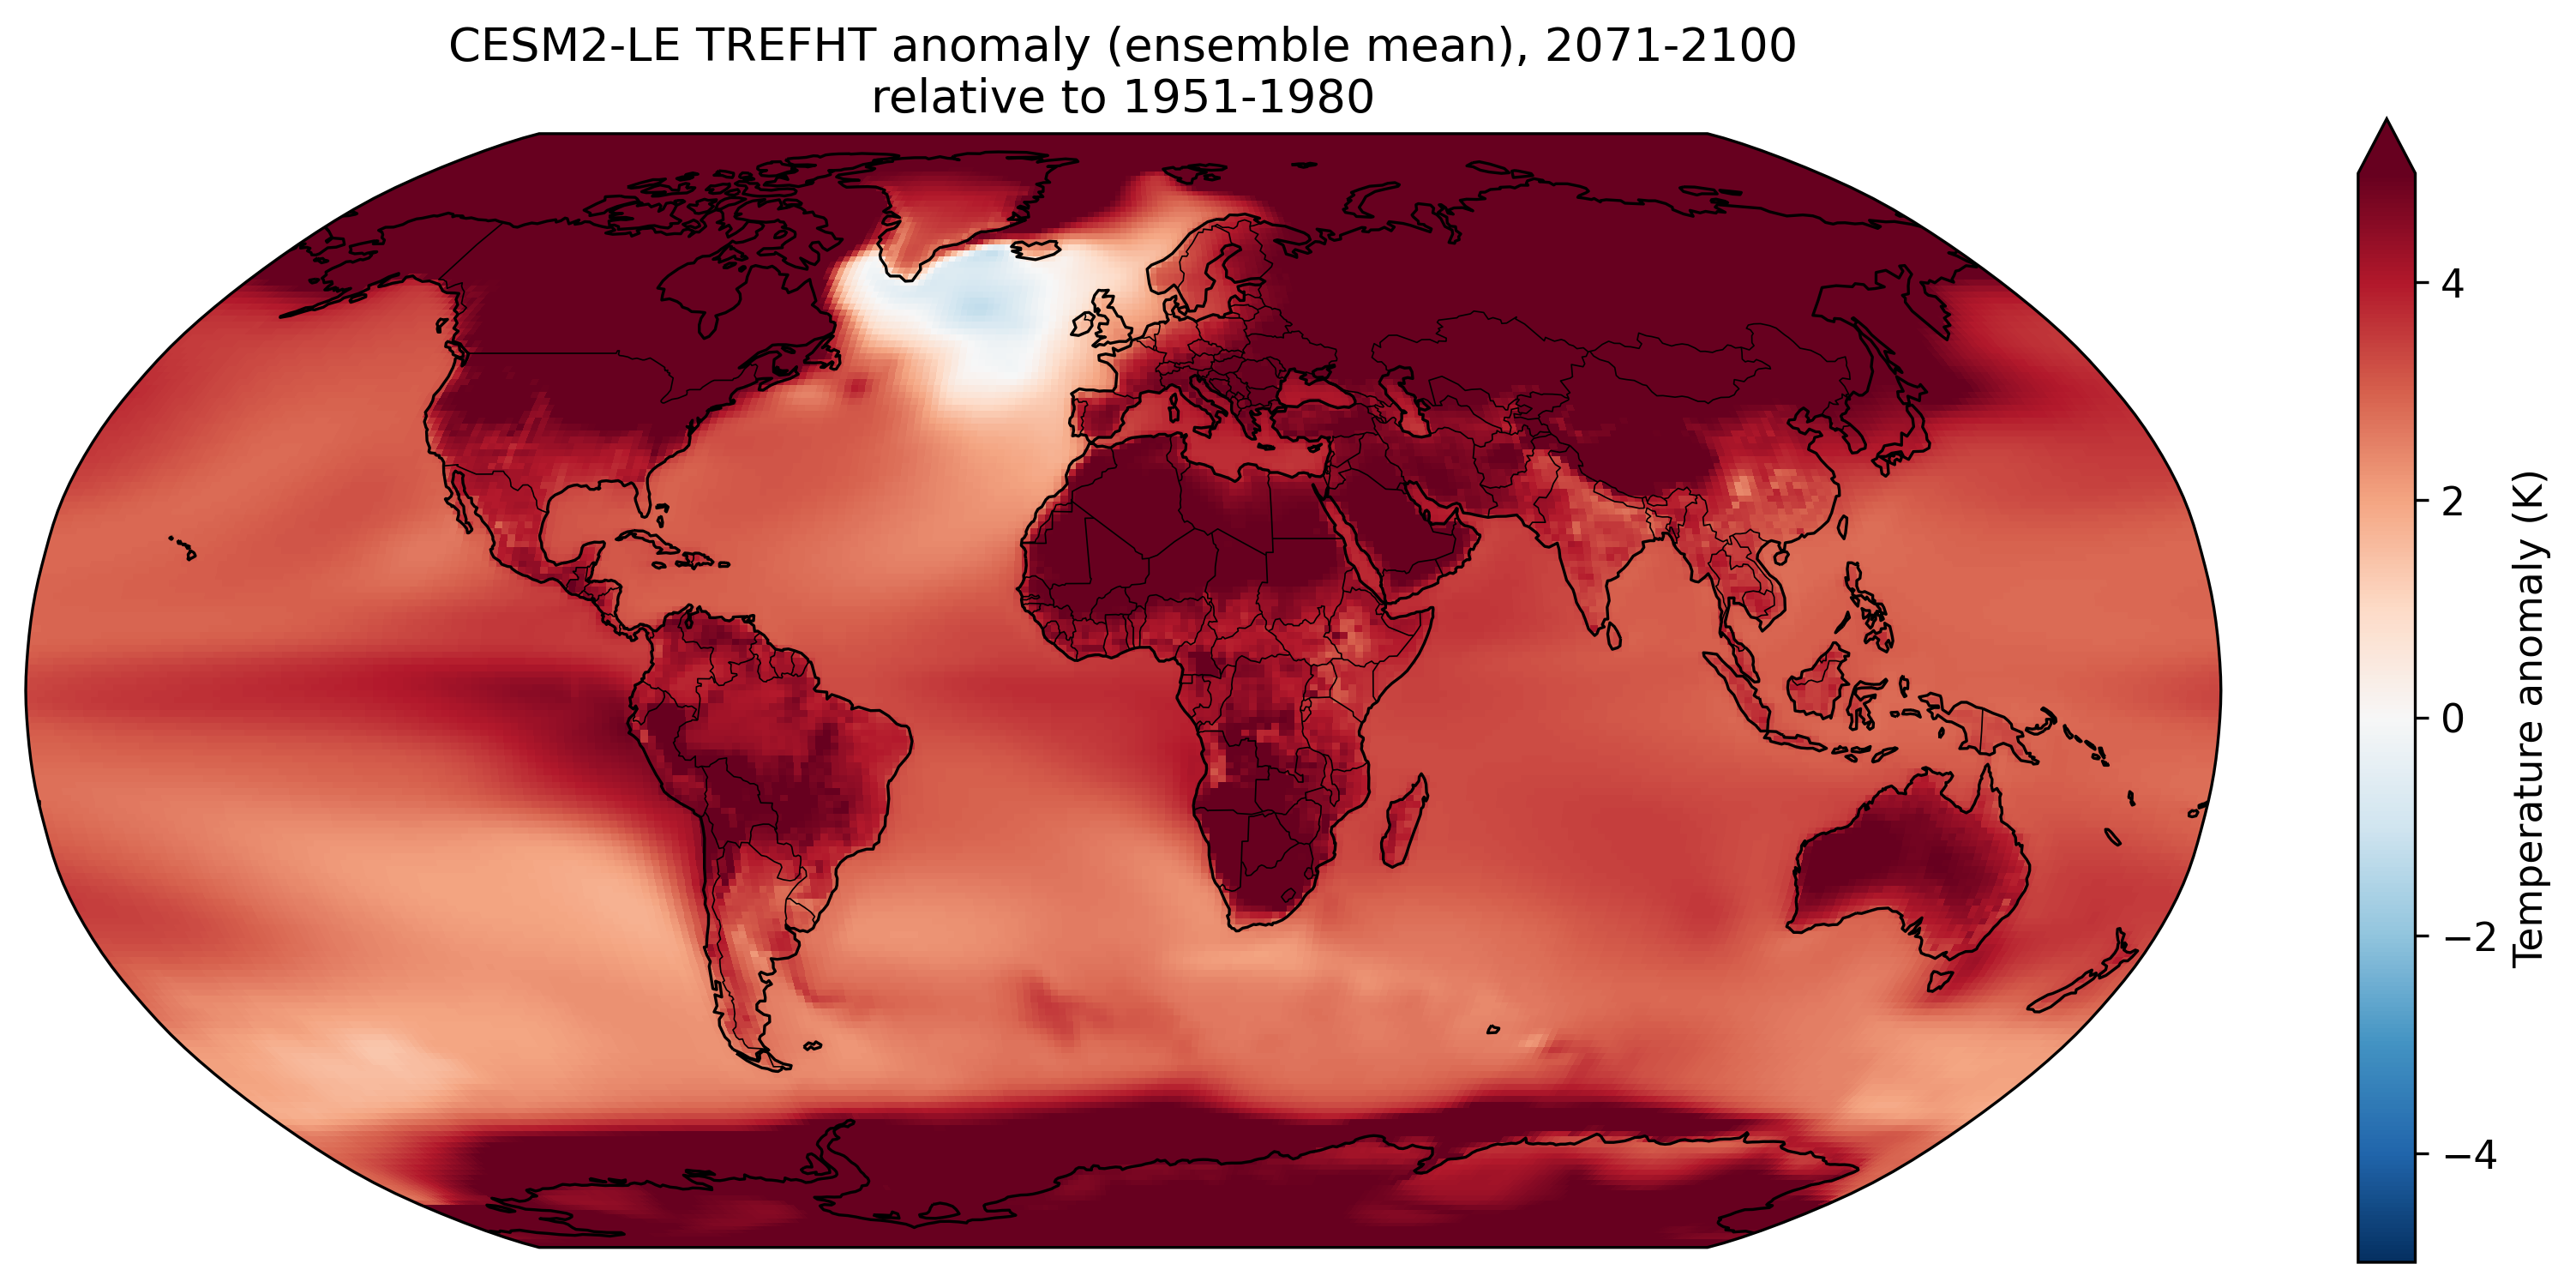

In [23]:

map2 = trefht_anom_ann_ensmean.sel(year=slice(2071, 2100)).mean("year")

plot_map(
    map2,
    "CESM2-LE TREFHT anomaly (ensemble mean), 2071-2100\nrelative to 1951-1980",
    outfile=os.path.join(OUTDIR, "map_trefht_anomaly_2071_2100.png"),
    vmin=-5,
    vmax=5
)


## 8. Compute global weighted annual mean time series for all 10 members

In [13]:

trefht_glb = global_weighted_mean_latlon(trefht_anom_ann)
trefht_glb_ensmean = trefht_glb.mean("ensemble")
trefht_glb


<xarray.DataArray 'TREFHT' (ensemble: 10, year: 252)> Size: 20kB
dask.array<truediv, shape=(10, 252), dtype=float64, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * ensemble  (ensemble) object 80B 'LE2-1001.001' ... 'LE2-1181.010'
  * year      (year) int64 2kB 1850 1851 1852 1853 1854 ... 2098 2099 2100 2101

## 9. Read NASA GISS observations and compute annual global weighted mean

In [14]:

print(f"Reading NASA GISS file: {GISS_PATH}")
giss = xr.open_dataset(GISS_PATH, decode_times=True, engine="netcdf4")

giss_tanom = giss["tempanomaly"]
giss_ann = annual_mean(giss_tanom)
giss_glb = global_weighted_mean_latlon(giss_ann)

giss_year_min = int(giss_glb["year"].min())
giss_year_max = int(giss_glb["year"].max())
cesm_year_min = int(trefht_glb["year"].min())
cesm_year_max = int(trefht_glb["year"].max())

overlap_start = max(giss_year_min, cesm_year_min)
overlap_end = min(giss_year_max, cesm_year_max)

giss_glb_overlap = giss_glb.sel(year=slice(overlap_start, overlap_end))

print(f"GISS/CESM overlap years: {overlap_start} to {overlap_end}")
giss_glb_overlap


Reading NASA GISS file: /glade/work/kumar34/GSEI2070_DAT/gistemp1200_GHCNv4_ERSSTv5.nc
GISS/CESM overlap years: 1880 to 2026


<xarray.DataArray 'tempanomaly' (year: 147)> Size: 588B
array([-0.19217902, -0.09684828, -0.13258164, -0.20516427, -0.30579627,
       -0.36311182, -0.35084844, -0.38095602, -0.18590645, -0.1230844 ,
       -0.3726539 , -0.23190238, -0.30450508, -0.3305146 , -0.32750303,
       -0.24099746, -0.13842589, -0.12738773, -0.2925831 , -0.19040026,
       -0.09781461, -0.16657147, -0.30120313, -0.38805106, -0.48080924,
       -0.26723126, -0.23123963, -0.40917027, -0.4326673 , -0.49484247,
       -0.45004204, -0.45673463, -0.37628207, -0.36645803, -0.17645887,
       -0.14789903, -0.37553135, -0.48226008, -0.32581598, -0.291136  ,
       -0.28764796, -0.19872648, -0.29637247, -0.2752939 , -0.2688853 ,
       -0.22371942, -0.10313012, -0.21926008, -0.19804913, -0.35634506,
       -0.15019032, -0.07646503, -0.1525773 , -0.28636652, -0.12075564,
       -0.19829741, -0.13745938, -0.01681176,  0.00129003, -0.01726093,
        0.13429193,  0.19215782,  0.06718911,  0.09340542,  0.20010509,
        0.09840513, -0.06516306, -0.01225262, -0.10035875, -0.10838857,
       -0.17522557, -0.06549088,  0.01548686,  0.09046573, -0.13174324,
       -0.13697878, -0.18193966,  0.05022359,  0.05986777,  0.02388862,
       -0.03006156,  0.05707319,  0.02861189,  0.05634945, -0.19840124,
       -0.11224742, -0.05950143, -0.01756494, -0.07850929,  0.0488167 ,
        0.0249448 , -0.08486992, -0.00227567,  0.1660793 , -0.06057334,
       -0.02052872, -0.10807279,  0.17781752,  0.06320681,  0.15866731,
        0.2567049 ,  0.32453722,  0.12601066,  0.31062877,  0.15718348,
        0.11275321,  0.16855404,  0.3060352 ,  0.3862364 ,  0.27069673,
        0.43585148,  0.41000256,  0.21821238,  0.2271473 ,  0.31287733,
        0.44102988,  0.3413754 ,  0.4578909 ,  0.607692  ,  0.37161496,
        0.392904  ,  0.5295583 ,  0.6281291 ,  0.6179698 ,  0.5307598 ,
        0.6764173 ,  0.6367098 ,  0.66849625,  0.5368823 ,  0.6561488 ,
        0.7226513 ,  0.6043738 ,  0.6361198 ,  0.6782485 ,  0.74078673,
        0.88330096,  1.0160861 ,  0.9127917 ,  0.84614193,  0.9754108 ,
        1.0044084 ,  0.84829193,  0.8940816 ,  1.1663945 ,  1.2829473 ,
        1.1981349 ,  1.164928  ], dtype=float32)
Coordinates:
  * year     (year) int64 1kB 1880 1881 1882 1883 1884 ... 2023 2024 2025 2026

## 10. Plot global time series with NASA GISS overlay

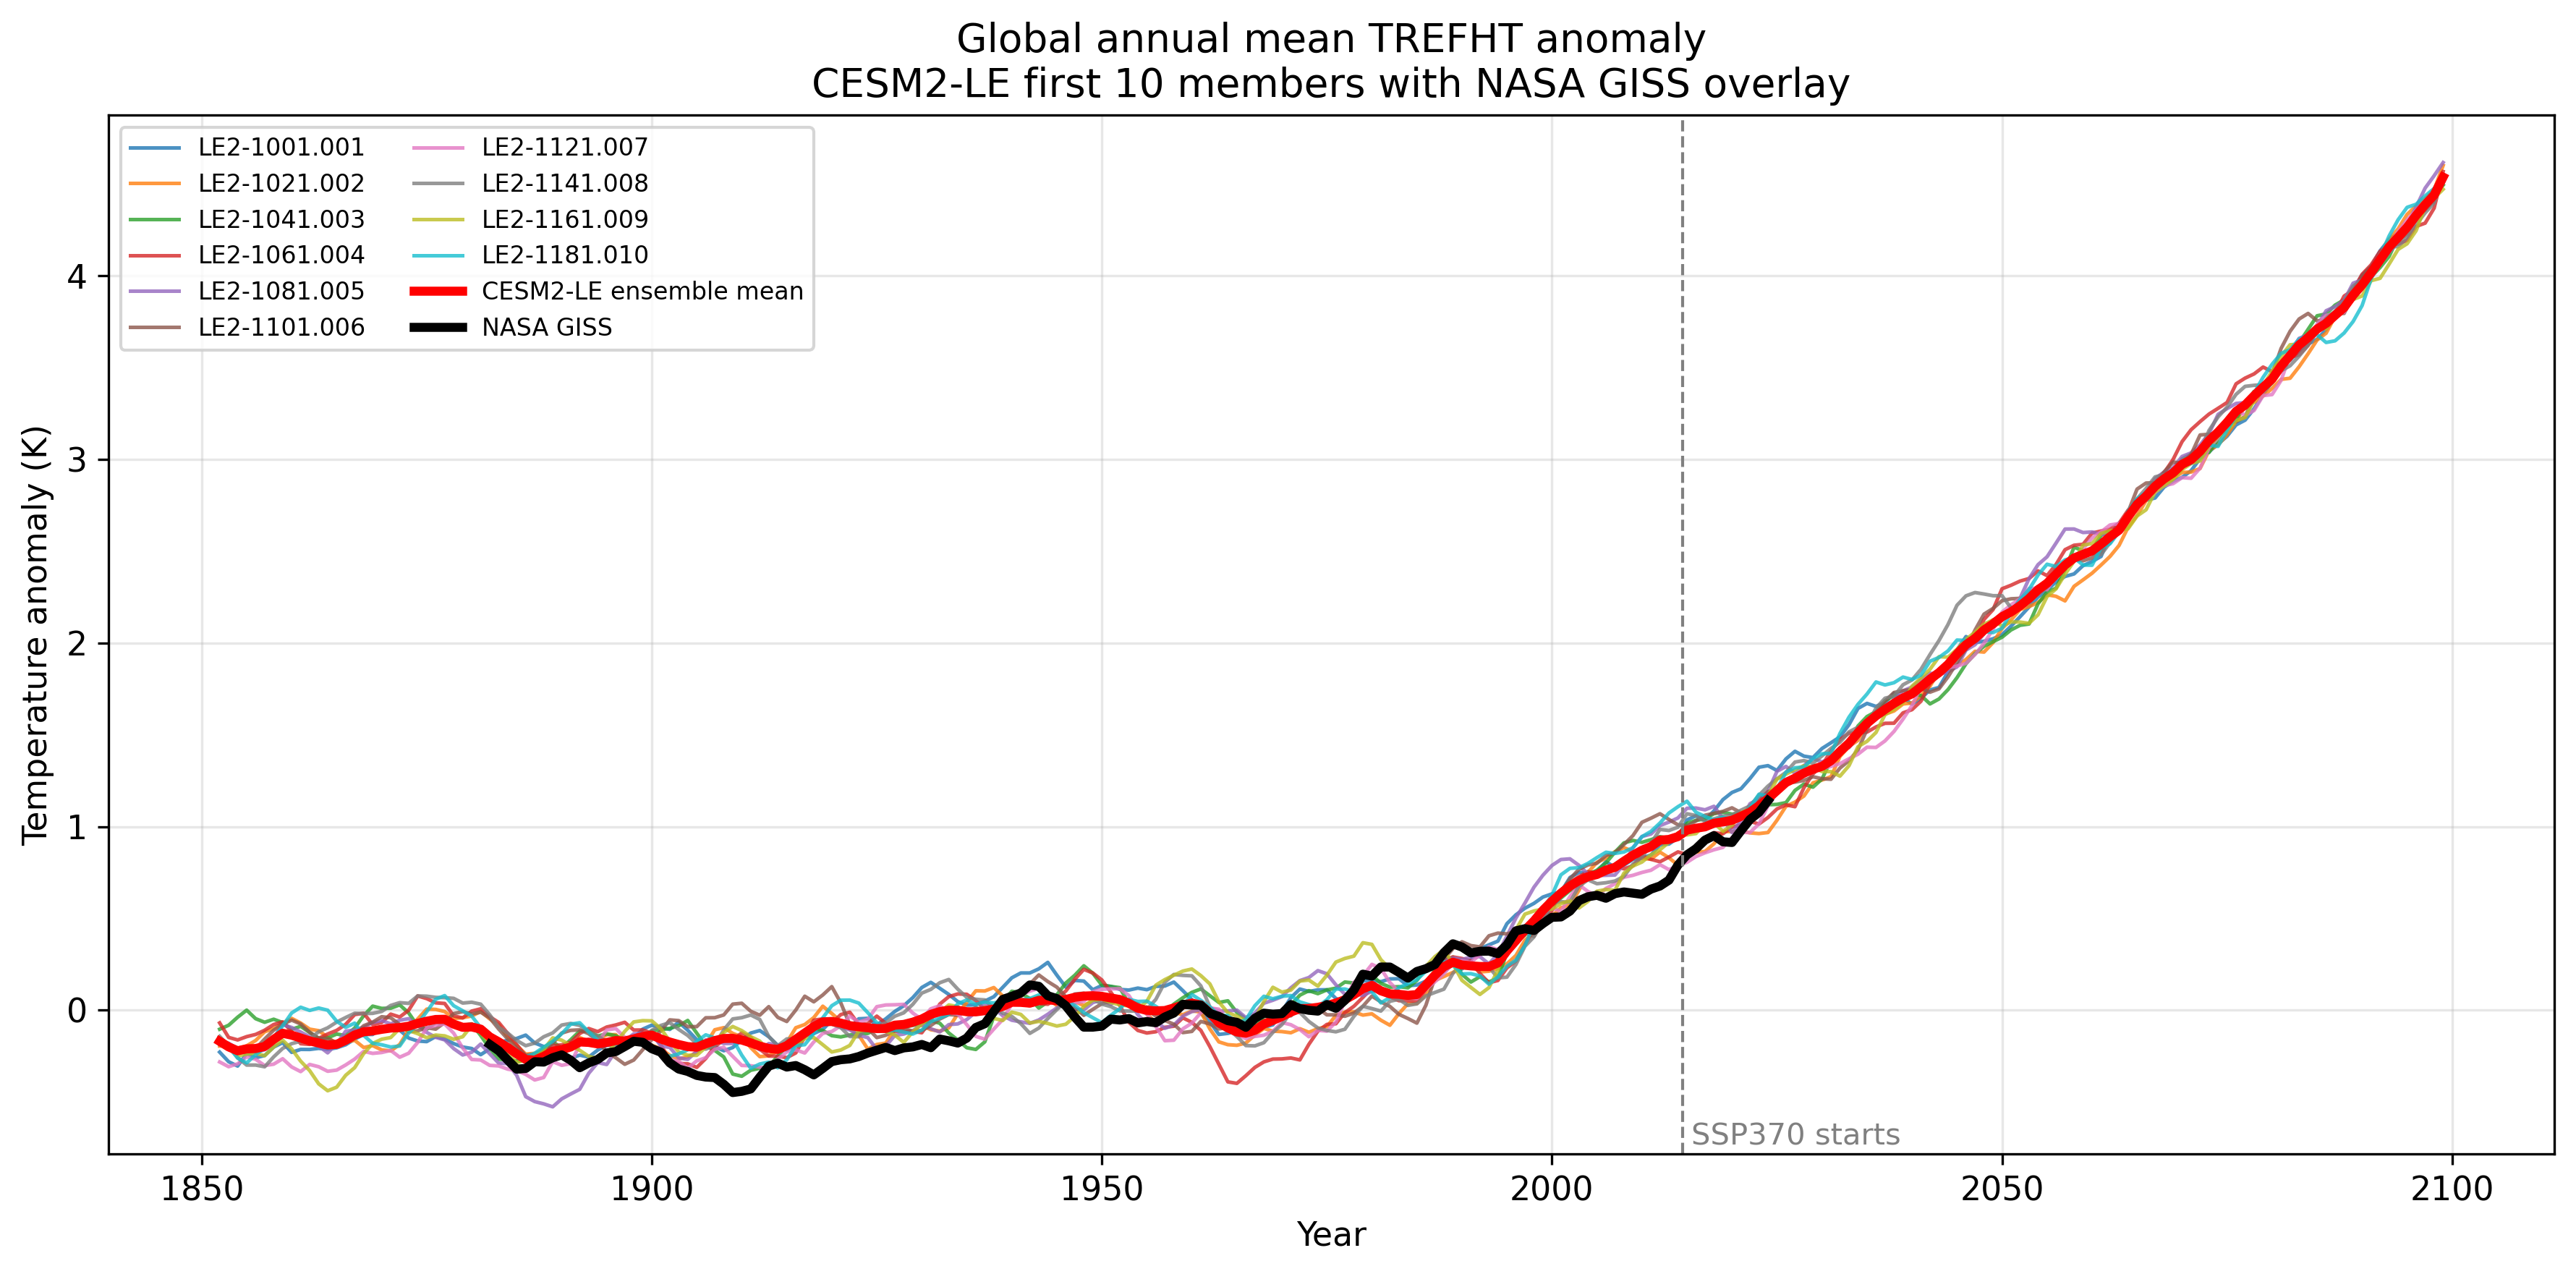

In [15]:

plt.figure(figsize=(12, 6))

for ens in trefht_glb["ensemble"].values:
    plt.plot(
        trefht_glb["year"],
        trefht_glb.sel(ensemble=ens).rolling(year=5, center=True).mean(),
        linewidth=1.2,
        alpha=0.8,
        label=str(ens)
    )

plt.plot(
    trefht_glb_ensmean["year"],
    trefht_glb_ensmean.rolling(year=5, center=True).mean(),
    color="red",
    linewidth=3.0,
    label="CESM2-LE ensemble mean"
)

plt.plot(
    giss_glb_overlap["year"],
    giss_glb_overlap.rolling(year=5, center=True).mean(),
    color="black",
    linewidth=3.0,
    label="NASA GISS"
)

plt.axvline(2014.5, color="gray", linestyle="--", linewidth=1)
plt.text(2015.5, plt.ylim()[0] + 0.05, "SSP370 starts", fontsize=10, color="gray")

plt.xlabel("Year")
plt.ylabel("Temperature anomaly (K)")
plt.title("Global annual mean TREFHT anomaly\nCESM2-LE first 10 members with NASA GISS overlay")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "global_timeseries_cesm2le_giss_overlay.png"),
            dpi=300, bbox_inches="tight")
plt.show()


## 11. NASA GISS observations - compute annual SE weighted mean

In [16]:
# --- SEUS subset for GISS --- 
# --- becasue GISS System in -180 to + 180 in logitude
giss_seus = giss_ann.sel(
    lat=slice(SEUS_LAT_MIN, SEUS_LAT_MAX),
    lon=slice(SEUS_LON_MIN-360.0, SEUS_LON_MAX-360.0)
)

# --- SEUS weighted mean ---
giss_seus_wgt = global_weighted_mean_latlon(giss_seus)

# --- Match overlap period ---
giss_seus_overlap = giss_seus_wgt.sel(
    year=slice(overlap_start, overlap_end)
)

## 12. Plot Southeastern U.S. weighted annual mean time series

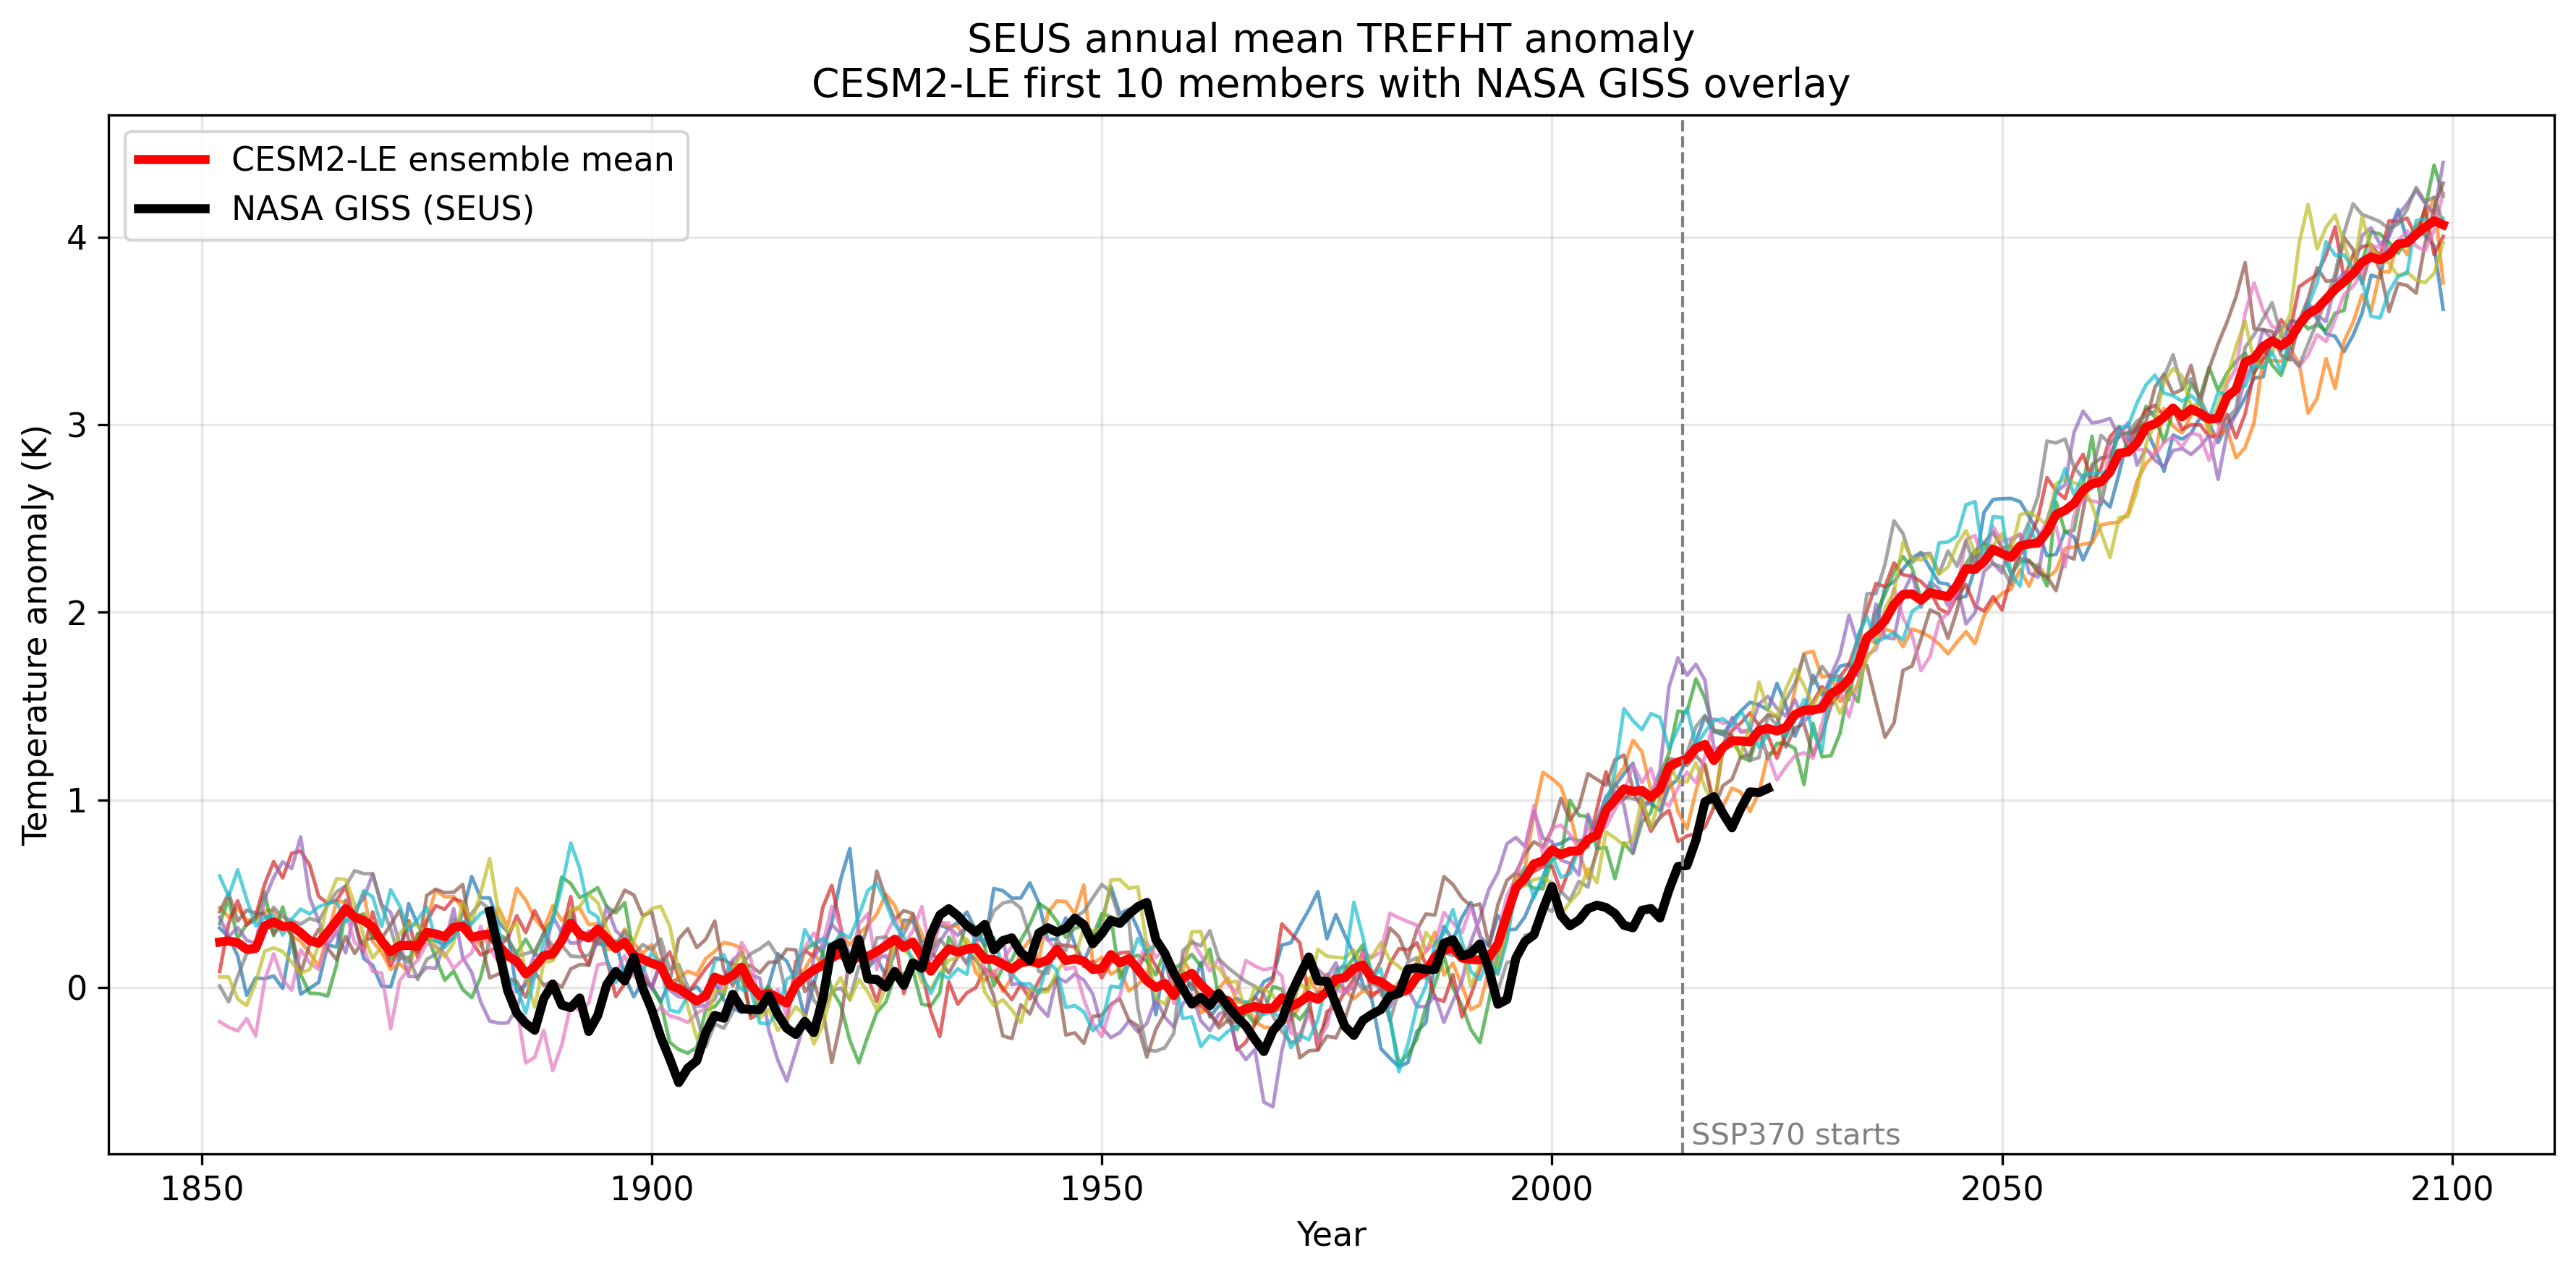

In [17]:
trefht_seus = subset_seus(trefht_anom_ann)
trefht_seus_wgt = global_weighted_mean_latlon(trefht_seus)
trefht_seus_ensmean = trefht_seus_wgt.mean("ensemble")

plt.figure(figsize=(12, 6))

# --- CESM ensemble members ---
for ens in trefht_seus_wgt["ensemble"].values:
    plt.plot(
        trefht_seus_wgt["year"],
        trefht_seus_wgt.sel(ensemble=ens).rolling(year=5, center=True).mean(),
        linewidth=1.2,
        alpha=0.7
    )

# --- CESM ensemble mean ---
plt.plot(
    trefht_seus_ensmean["year"],
    trefht_seus_ensmean.rolling(year=5, center=True).mean(),
    color="red",
    linewidth=3.0,
    label="CESM2-LE ensemble mean"
)

# --- NASA GISS (SEUS) ---
plt.plot(
    giss_seus_overlap["year"],
    giss_seus_overlap.rolling(year=5, center=True).mean(),
    color="black",
    linewidth=3.0,
    label="NASA GISS (SEUS)"
)

# --- Scenario divider ---
plt.axvline(2014.5, color="gray", linestyle="--", linewidth=1)
plt.text(2015.5, plt.ylim()[0] + 0.05, "SSP370 starts", fontsize=10, color="gray")

plt.xlabel("Year")
plt.ylabel("Temperature anomaly (K)")
plt.title("SEUS annual mean TREFHT anomaly\nCESM2-LE first 10 members with NASA GISS overlay")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(OUTDIR, "seus_timeseries_cesm2le_giss_overlay.png"),
            dpi=300, bbox_inches="tight")

plt.show()


## 12. Summary

This notebook produces:

- ensemble-mean spatial anomaly maps for **1981–2010** and **2071–2100**
- global weighted annual mean time series for **10 CESM2-LE members**
- NASA GISS observational overlay on the global time series
- Southeastern U.S. weighted annual mean time series

All figures are also saved in `OUTDIR`.


In [19]:
print("Finished successfully.")
print(f"Figures saved in: {OUTDIR}")

Finished successfully.
Figures saved in: ./figures_cesm2le


In [ ]:
#Questions :

In [ ]:
# d) The graph shows a clear warming trend over time.
# The model results follow the NASA GISS observations pretty closely in the past.
# There is some spread between lines, but they all show warming.
# By the end of the century, temperatures increase by about 4–5 K.

In [ ]:
# f) Auburn shows the same overall warming trend as the global data,
# but it has more ups and downs year to year.
# This is normal since local areas vary more than the global average.
# It still shows strong warming by the end of the century.